In [124]:
import warnings
warnings.filterwarnings('ignore')
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


In [125]:
path_input = '../data/'
path_output = '../figures/'

In [126]:
theta = np.linspace(0, 2*np.pi, 100)
x_circle = np.cos(theta)
y_circle = np.sin(theta)

x_circle_small = np.cos(theta)/2.5
y_circle_small = np.sin(theta)/2.5


arrow_length = 0.8  # Adjust length as needed
x_start = 0
y_start = 0
theta_rot = 0
x_end = x_start + arrow_length * np.cos(theta_rot*(+1))
y_end = y_start + arrow_length * np.sin(theta_rot*(+1))

props1 = dict(boxstyle='round', facecolor='w', alpha=1, linewidth = .5)
n_quiver = 15


def plot_composite(ax, compo_2D, vmin, vmax, cmap0):
    p1 = ax.pcolormesh(compo_2D.x, compo_2D.y,  compo_2D, vmin = vmin, vmax = vmax, cmap = cmap0)
    # levels = np.arange(np.nanmin(abs(compo_2D)), np.nanmax(abs(compo_2D)) + 0.1, 0.1)
    # ax.contour(compo_2D.x, compo_2D.y, compo_2D, levels=levels, colors='k')
    ax.plot(x_circle, y_circle, color = 'k', linewidth = 2)
    ax.plot(x_circle, y_circle, color = 'w', linewidth = .5, linestyle = '--')
    ax.set_xticks([-1, -.4, 0, .4, 1], ['-2.5$R_{max}$', '-$R_{max}$', '0', '$R_{max}$', '2.5$R_{max}$'], rotation = 90)
    ax.set_yticks([-1, -.4, 0, .4, 1], ['-2.5$R_{max}$', '-$R_{max}$', '0', '$R_{max}$', '2.5$R_{max}$'])

    
    ax.plot(x_circle_small, y_circle_small, color = 'k', linewidth = 2)
    ax.plot(x_circle_small, y_circle_small, color = 'w', linewidth = .5)
    ax.plot(x_circle, y_circle, color = 'k', linewidth = 2)
    ax.plot(x_circle, y_circle, color = 'w', linewidth = .5, linestyle = '--')

    return p1

In [127]:

###########
# --- GS2
###########
ds_GS = xr.open_dataset(path_input + 'composite_vort_GS.nc')

vort_GS2_cyclonic = ds_GS.vort_swot_cyc
vort_GS2_DUACS_cyclonic = ds_GS.vort_swot_cyc_DUACS
vort_GS2_anticyclonic = ds_GS.vort_swot_anticyc
vort_GS2_DUACS_anticyclonic = ds_GS.vort_swot_anticyc_DUACS

###########
# --- AGULHAS
###########

ds_AGULHAS = xr.open_dataset(path_input + 'composite_vort_AGULHAS.nc')

vort_AGULHAS_cyclonic = ds_AGULHAS.vort_swot_cyc
vort_AGULHAS_DUACS_cyclonic = ds_AGULHAS.vort_swot_cyc_DUACS
vort_AGULHAS_anticyclonic = ds_AGULHAS.vort_swot_anticyc
vort_AGULHAS_DUACS_anticyclonic = ds_AGULHAS.vort_swot_anticyc_DUACS


###########
# --- CCS
###########

ds_CCS = xr.open_dataset(path_input + 'composite_vort_CCS.nc')


vort_CCS_cyclonic = ds_CCS.vort_swot_cyc
vort_CCS_DUACS_cyclonic = ds_CCS.vort_swot_cyc_DUACS
vort_CCS_anticyclonic = ds_CCS.vort_swot_anticyc
vort_CCS_DUACS_anticyclonic = ds_CCS.vort_swot_anticyc_DUACS




###########
# --- ACC-1
###########

ds_ACC1 = xr.open_dataset(path_input + 'composite_vort_ACC1.nc')


vort_ACC1_bis_cyclonic = ds_ACC1.vort_swot_cyc
vort_ACC1_bis_DUACS_cyclonic = ds_ACC1.vort_swot_cyc_DUACS
vort_ACC1_bis_anticyclonic = ds_ACC1.vort_swot_anticyc
vort_ACC1_bis_DUACS_anticyclonic = ds_ACC1.vort_swot_anticyc_DUACS

###########
# --- ACC-2
###########

ds_ACC2 = xr.open_dataset(path_input + 'composite_vort_ACC2.nc')


vort_ACC2_cyclonic = ds_ACC2.vort_swot_cyc
vort_ACC2_DUACS_cyclonic = ds_ACC2.vort_swot_cyc_DUACS
vort_ACC2_anticyclonic = ds_ACC2.vort_swot_anticyc
vort_ACC2_DUACS_anticyclonic = ds_ACC2.vort_swot_anticyc_DUACS


###########
# --- MED
###########

ds_MED = xr.open_dataset(path_input + 'composite_vort_MED.nc')


vort_MED_cyclonic = ds_MED.vort_swot_cyc
vort_MED_DUACS_cyclonic = ds_MED.vort_swot_cyc_DUACS
vort_MED_anticyclonic = ds_MED.vort_swot_anticyc
vort_MED_DUACS_anticyclonic = ds_MED.vort_swot_anticyc_DUACS





In [128]:
omega = 7.2921e-5
# latitudes
lat_GS2 = 33
lat_AGULHAS = -36.5
lat_CCS = 37
lat_ACC1 = -50.5
lat_ACC2 = -57.5
lat_MED = 38.7

# Coriolis parameters

f_GS2 = 2 * omega* np.sin(np.deg2rad(lat_GS2))
f_AGULHAS = 2 * omega* np.sin(np.deg2rad(lat_AGULHAS))
f_CCS = 2 * omega* np.sin(np.deg2rad(lat_CCS))
f_ACC1 = 2 * omega* np.sin(np.deg2rad(lat_ACC1))
f_ACC2 = 2 * omega* np.sin(np.deg2rad(lat_ACC2))
f_MED = 2 * omega* np.sin(np.deg2rad(lat_MED))


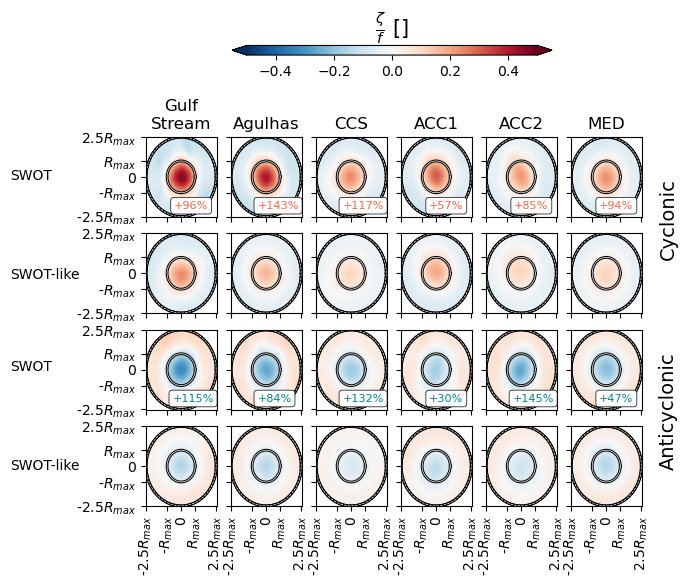

In [129]:
fig, axes = plt.subplots(ncols = 6, nrows = 4, sharex = True, sharey = True)
vmin = -.5
vmax = .5
ax = axes[0][0]
p1 = plot_composite(ax, vort_GS2_cyclonic/f_GS2, vmin, vmax, 'RdBu_r')
ax.set_title('Gulf\nStream')
ax.text(-.2, -.8, '+96%', color = 'tomato', bbox = props1, fontsize = 8)

ax = axes[1][0]
_ = plot_composite(ax, vort_GS2_DUACS_cyclonic/f_GS2, vmin, vmax, 'RdBu_r')


ax = axes[2][0]
_ = plot_composite(ax, vort_GS2_anticyclonic/f_GS2, vmin, vmax, 'RdBu_r')

ax.text(-.25, -.8, '+115%', color = 'teal', bbox = props1, fontsize = 8)

ax = axes[3][0]
_ = plot_composite(ax, vort_GS2_DUACS_anticyclonic/f_GS2, vmin, vmax, 'RdBu_r')


ax = axes[0][1]
_ = plot_composite(ax, vort_AGULHAS_cyclonic/f_AGULHAS, vmin, vmax, 'RdBu_r')
ax.text(-.25, -.8, '+143%', color = 'tomato', bbox = props1, fontsize = 8)


ax.set_title('Agulhas')

ax = axes[1][1]
p1 = plot_composite(ax, vort_AGULHAS_DUACS_cyclonic/f_AGULHAS, vmin, vmax, 'RdBu_r')


ax = axes[2][1]
_ = plot_composite(ax, vort_AGULHAS_anticyclonic/f_AGULHAS, vmin, vmax, 'RdBu_r')
ax.text(-.25, -.8, '+84%', color = 'teal', bbox = props1, fontsize = 8)

ax = axes[3][1]
_ = plot_composite(ax, vort_AGULHAS_DUACS_anticyclonic/f_AGULHAS, vmin, vmax, 'RdBu_r')

ax = axes[0][2]


p1 = plot_composite(ax, vort_CCS_cyclonic/f_CCS, vmin, vmax, 'RdBu_r')
ax.text(-.25, -.8, '+117%', color = 'tomato', bbox = props1, fontsize = 8)
ax.set_title('CCS')

ax = axes[1][2]
_ = plot_composite(ax, vort_CCS_DUACS_cyclonic/f_CCS, vmin, vmax, 'RdBu_r')

ax = axes[2][2]
_ = plot_composite(ax, vort_CCS_anticyclonic/f_CCS, vmin, vmax, 'RdBu_r')
ax.text(-.25, -.8, '+132%', color = 'teal', bbox = props1, fontsize = 8)

ax = axes[3][2]
_ = plot_composite(ax, vort_CCS_DUACS_anticyclonic/f_CCS, vmin, vmax, 'RdBu_r')


ax = axes[0][3]


p1 = plot_composite(ax, vort_ACC1_bis_cyclonic/f_ACC1, vmin, vmax, 'RdBu_r')
ax.text(-.2, -.8, '+57%', color = 'tomato', bbox = props1, fontsize = 8)

ax.set_title('ACC1')

ax = axes[1][3]
_ = plot_composite(ax, vort_ACC1_bis_DUACS_cyclonic/f_ACC1, vmin, vmax, 'RdBu_r')

ax = axes[2][3]
_ = plot_composite(ax, vort_ACC1_bis_anticyclonic/f_ACC1, vmin, vmax, 'RdBu_r')
ax.text(-.2, -.8, '+30%', color = 'teal', bbox = props1, fontsize = 8)

ax = axes[3][3]
_ = plot_composite(ax, vort_ACC1_bis_DUACS_anticyclonic/f_ACC1, vmin, vmax, 'RdBu_r')


ax = axes[0][4]

ax.set_title('ACC2')

p1 = plot_composite(ax, vort_ACC2_cyclonic/f_ACC2, vmin, vmax, 'RdBu_r')
ax.text(-.2, -.8, '+85%', color = 'tomato', bbox = props1, fontsize = 8)
ax = axes[1][4]
_ = plot_composite(ax, vort_ACC2_DUACS_cyclonic/f_ACC2, vmin, vmax, 'RdBu_r')

ax = axes[2][4]
_ = plot_composite(ax, vort_ACC2_anticyclonic/f_ACC2, vmin, vmax, 'RdBu_r')
ax.text(-.25, -.8, '+145%', color = 'teal', bbox = props1, fontsize = 8)
ax = axes[3][4]
_ = plot_composite(ax, vort_ACC2_DUACS_anticyclonic/f_ACC2, vmin, vmax, 'RdBu_r')




ax = axes[0][5]

ax.set_title('MED')
p1 = plot_composite(ax, vort_MED_cyclonic/f_MED,  vmin, vmax,  'RdBu_r')
ax.text(-.2, -.8, '+94%', color = 'tomato', bbox = props1, fontsize = 8)


ax = axes[1][5]
_ = plot_composite(ax, vort_MED_DUACS_cyclonic/f_MED,  vmin, vmax,  'RdBu_r')


ax = axes[2][5]
_ = plot_composite(ax, vort_MED_anticyclonic/f_MED,  vmin, vmax,  'RdBu_r')
ax.text(-.2, -.8, '+47%', color = 'teal', bbox = props1, fontsize = 8)

ax = axes[3][5]
_ = plot_composite(ax, vort_MED_DUACS_anticyclonic/f_MED, vmin, vmax,  'RdBu_r')



cax = fig.add_axes([.26, 1.05, .5, 0.02])
cbar = plt.colorbar(p1, cax = cax, orientation = 'horizontal', extend = 'both')
cbar.ax.set_title('$\\frac{\\zeta}{f}$ []' ,fontsize = 15)
ax.text(-17, -.1, 'SWOT-like')
ax.text(-17, 2.4, 'SWOT')
ax.text(-17, 4.7, 'SWOT-like')
ax.text(-17, 7.2, 'SWOT')

ax.text(1.5, 0, 'Anticyclonic', rotation = 90, fontsize = 14)
ax.text(1.5, 5.3, 'Cyclonic', rotation = 90, fontsize = 14)
plt.savefig(path_output + 'Fig3.png', dpi = 300, bbox_inches = 'tight')
